# Exp08a — Maker Execution Feasibility Study

### Bounded Claim Statement

> **This experiment does NOT test whether maker alpha exists globally.**
> It tests whether micro-drift observed in Exp07 (EER=Low+Vol=Low,
> P(cont@3c)=54.6%, n=194 train) survives realistic **retail** maker execution assumptions.

**What this is:** execution survivability research.
**What this is NOT:** strategy profitability or general alpha discovery.

### Key Metrics
| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **FQR** | `E[ret|filled] / E[ret|signal]` | <0.70 = adverse selection dominates |
| **MOR** | `P(profitable AND not filled)` | High = good trades escape |
| **HET** | `E_net[fantasy] - E_net[retail]` | Hidden execution tax |
| **Eff. Gap Ratio** | `required_drift / adj_drift` | <5x = potentially viable |

### GO Criteria for Exp08b
```
ALL must pass:
  [ ] FQR > 0.70
  [ ] Effective Gap Ratio < 5x
  [ ] E_net robust across Models A / B / C / D
```

### Prior Experiments
| Exp | Family | Result |
|-----|--------|--------|
| 01-03 | EMA/Stoch | NO-GO |
| 04-05B | Session Breakout | NO-GO |
| 06a/06a.1 | VWAP | NO-GO (97% drift contamination) |
| 07 | Vol Expansion | NO-GO (P(cont)=48%, rv_ratio=0.80) |

Only candidate: EER=Low+Vol=Low, P(cont@3c)=54.6%, n=194 train.


In [13]:
import hashlib, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')

REPO_ROOT  = Path('C:/Users/Lenovo/Documents/TRADING-BOT')
DATA_FILE  = REPO_ROOT / 'data' / 'raw' / 'BTCUSDT_M1.csv'
OUTPUT_DIR = REPO_ROOT / 'research' / 'experiments' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# FROZEN PARAMS — identical to Exp07 SPEC_HASH c4eea0bd7574
ATR_WINDOW        = 20
PERCENTILE_WINDOW = 500
EER_HIGH          = 0.65
EER_LOW           = 0.40
VOL_HIGH_PCT      = 0.90
VOL_LOW_PCT       = 0.50
ATR_THRESH        = 2.0
SPLIT_DATE        = pd.Timestamp('2026-03-29', tz='UTC')
FWD_HORIZONS      = [1, 3, 5, 10, 20]
PRIMARY_HORIZON   = 3
FILL_HORIZONS     = [1, 3, 5]

# Execution model (retail-conservative)
MAKER_REBATE  = -0.0002   # +0.02% standard Binance maker (non-VIP)
TAKER_COST    =  0.0008   # 2x0.04% — Exp01-07 baseline
FILL_EPSILON  =  0.0001   # 0.01% buffer for touch-through (Model C)
FQR_GO        = 0.70
GAP_RATIO_GO  = 5.0
N_BOOTSTRAP   = 1000

SPEC = {
    'version': '08a-v1', 'prior_exp': 'c4eea0bd7574',
    'objective': 'execution_survivability',
    'signal': 'TR/ATR>2.0 AND EER=Low AND Vol=Low',
    'params': {
        'ATR_WINDOW': ATR_WINDOW, 'EER_LOW': EER_LOW,
        'VOL_LOW_PCT': VOL_LOW_PCT, 'ATR_THRESH': ATR_THRESH,
        'MAKER_REBATE': MAKER_REBATE, 'FILL_EPSILON': FILL_EPSILON,
    }
}
SPEC_HASH = hashlib.sha256(json.dumps(SPEC, sort_keys=True).encode()).hexdigest()[:12]

print('Cell 2 OK — Exp08a: Maker Execution Feasibility Study')
print(f'SPEC_HASH: {SPEC_HASH}')
print(f'Prior (Exp07): c4eea0bd7574 — signal params FROZEN')
print(f'Maker rebate={MAKER_REBATE*100:+.2f}%  Taker cost={TAKER_COST*100:.3f}%')
print(f'Fill models: A=open_C+1  B=touch-only  C=touch-through  D=cross-through')
print(f'GO criteria: FQR>{FQR_GO}  EffGapRatio<{GAP_RATIO_GO}x  robust across all models')


Cell 2 OK — Exp08a: Maker Execution Feasibility Study
SPEC_HASH: 3875a863a4fe
Prior (Exp07): c4eea0bd7574 — signal params FROZEN
Maker rebate=-0.02%  Taker cost=0.080%
Fill models: A=open_C+1  B=touch-only  C=touch-through  D=cross-through
GO criteria: FQR>0.7  EffGapRatio<5.0x  robust across all models


In [14]:
# Load + feature engineering (identical pipeline to Exp07)
df = pd.read_csv(DATA_FILE)
df['open_time'] = pd.to_datetime(df['open_time'], unit='ms', utc=True)
df = df.sort_values('open_time').reset_index(drop=True)
for col in ['open', 'high', 'low', 'close', 'volume']:
    df[col] = df[col].astype(float)
df['date'] = df['open_time'].dt.date

print(f'Loaded: {len(df):,} M1 candles')
print(f'Range:  {df["open_time"].iloc[0].date()} -> {df["open_time"].iloc[-1].date()}')

# True Range + ATR
prev_close = df['close'].shift(1)
df['tr']   = np.maximum(df['high'] - df['low'],
             np.maximum((df['high'] - prev_close).abs(),
                        (df['low']  - prev_close).abs()))
df['atr']      = df['tr'].rolling(ATR_WINDOW, min_periods=ATR_WINDOW//2).mean()
df['tr_ratio'] = df['tr'] / df['atr']

# EER
body         = (df['close'] - df['open']).abs()
candle_range = (df['high']  - df['low']).replace(0, np.nan)
df['eer']    = (body / candle_range).clip(0, 1)
df['dir_sign'] = np.where(df['close'] >= df['open'], 1.0, -1.0)

# Volume percentile (rolling)
df['vol_pct'] = df['volume'].rolling(PERCENTILE_WINDOW, min_periods=50).rank(pct=True)

# EER + Volume buckets (identical to Exp07)
df['eer_bucket'] = pd.cut(df['eer'],
    bins=[-0.01, EER_LOW, EER_HIGH, 1.01], labels=['Low', 'Med', 'High'])
df['vol_bucket'] = pd.cut(df['vol_pct'],
    bins=[-0.01, VOL_LOW_PCT, VOL_HIGH_PCT, 1.01], labels=['Low', 'Med', 'High'])
df['bin'] = df['eer_bucket'].astype(str) + '+' + df['vol_bucket'].astype(str)

# Forward closes (within-day)
MAX_H = max(FWD_HORIZONS)
for h in range(1, MAX_H + 1):
    df[f'fwd_c{h}'] = df.groupby('date')['close'].shift(-h)
df['fwd_open1'] = df.groupby('date')['open'].shift(-1)

# Direction-signed continuation return (from close_C)
for h in FWD_HORIZONS:
    df[f'cont_{h}c'] = (df[f'fwd_c{h}'] - df['close']) * df['dir_sign'] / df['close']

# Forward rolling min-low / max-high for fill models B/C
# fwd_min_low_N at i = min(low[i+1..i+N]) = rolling(N).min().shift(-N)
for h in FILL_HORIZONS:
    df[f'fwd_min_low_{h}']  = df['low'].rolling(h).min().shift(-h)
    df[f'fwd_max_high_{h}'] = df['high'].rolling(h).max().shift(-h)

# Train / holdout split
df['split'] = np.where(df['open_time'] < SPLIT_DATE, 'train', 'holdout')
train   = df[df['split'] == 'train'].copy()
holdout = df[df['split'] == 'holdout'].copy()

# Signal definition
train['is_burst']  = train['tr_ratio'] > ATR_THRESH
train['is_signal'] = train['is_burst'] & (train['bin'] == 'Low+Low')

n_burst  = train['is_burst'].sum()
n_signal = train['is_signal'].sum()
print(f'Total burst events (TR/ATR > {ATR_THRESH}): {n_burst:,}')
print(f'EER=Low+Vol=Low signals: {n_signal}  ({n_signal/n_burst*100:.1f}% of bursts)')
print()
print('All bin counts (burst events, train):')
for b, cnt in train[train['is_burst']]['bin'].value_counts().sort_index().items():
    flag = '  <- PRIMARY (Exp07 candidate)' if b == 'Low+Low' else ''
    print(f'  {b}: n={cnt:,}{flag}')
print('Cell 3 OK')


Loaded: 518,401 M1 candles
Range:  2025-05-29 -> 2026-05-24
Total burst events (TR/ATR > 2.0): 37,681
EER=Low+Vol=Low signals: 197  (0.5% of bursts)

All bin counts (burst events, train):
  High+High: n=9,019
  High+Low: n=5,468
  High+Med: n=14,223
  Low+High: n=2,024
  Low+Low: n=197  <- PRIMARY (Exp07 candidate)
  Low+Med: n=1,358
  Med+High: n=2,765
  Med+Low: n=379
  Med+Med: n=2,244
Cell 3 OK


In [15]:
# Q1 — Fill Probability Curves
SEP = '=' * 68
print(SEP)
print('Q1 - FILL PROBABILITY CURVES')
print('A=always(open_C+1)  B=touch-only  C=touch-through  D=cross-through')
print(SEP)

def compute_fill_flags(subset):
    res = {}
    long_m  = subset['dir_sign'] ==  1.0
    short_m = subset['dir_sign'] == -1.0
    cl0     = subset['close']
    eps     = cl0 * FILL_EPSILON
    for h in FILL_HORIZONS:
        minl = subset[f'fwd_min_low_{h}']
        maxh = subset[f'fwd_max_high_{h}']
        clsx = subset.get(f'fwd_c{h}', pd.Series(dtype=float))
        res[f'B_{h}c'] = (long_m & (minl <= cl0)) | (short_m & (maxh >= cl0))
        res[f'C_{h}c'] = (long_m & (minl < cl0 - eps)) | (short_m & (maxh > cl0 + eps))
        if f'fwd_c{h}' in subset.columns:
            res[f'D_{h}c'] = (long_m & (subset[f'fwd_c{h}'] < cl0)) | (short_m & (subset[f'fwd_c{h}'] > cl0))
    return res

sig_all  = train[train['is_burst']].dropna(subset=[f'cont_{PRIMARY_HORIZON}c']).copy()
sig_prim = train[train['is_signal']].dropna(subset=[f'cont_{PRIMARY_HORIZON}c']).copy()

fills_all  = compute_fill_flags(sig_all)
fills_prim = compute_fill_flags(sig_prim)

# Store fill flags in subsets for downstream cells
for key, series in fills_all.items():
    sig_all[f'fill_{key}'] = series.values
for key, series in fills_prim.items():
    sig_prim[f'fill_{key}'] = series.values

header = f'{"Model":<6}' + ''.join(f'  {"N="+str(h)+"c":>7}' for h in FILL_HORIZONS)
for label, subset, fill_dict in [
    (f'ALL burst events (n={len(sig_all):,})', sig_all, fills_all),
    (f'EER=Low+Vol=Low (n={len(sig_prim)})', sig_prim, fills_prim),
]:
    print(f'\n  {label}:')
    print(f'  {header}')
    print(f'  {"A":<6}' + '  '.join(f'  {"100.0%":>7}' for _ in FILL_HORIZONS))
    for m in ['B', 'C', 'D']:
        vals = []
        for h in FILL_HORIZONS:
            key = f'{m}_{h}c'
            if key in fill_dict:
                vals.append(f'{fill_dict[key].mean()*100:>7.1f}%')
            else:
                vals.append(f'{"N/A":>7}')
        print(f'  {m:<6}' + '  '.join(f'  {v}' for v in vals))

print()
print('Key: High P(fill,B) vs P(fill,C) = 1-tick optimism bias matters at this drift scale')
print('Cell 4 OK')


Q1 - FILL PROBABILITY CURVES
A=always(open_C+1)  B=touch-only  C=touch-through  D=cross-through

  ALL burst events (n=37,625):
  Model      N=1c     N=3c     N=5c
  A        100.0%     100.0%     100.0%
  B          98.0%       98.7%       99.0%
  C          55.0%       69.9%       75.8%
  D          48.6%       50.8%       51.0%

  EER=Low+Vol=Low (n=196):
  Model      N=1c     N=3c     N=5c
  A        100.0%     100.0%     100.0%
  B          98.5%       99.5%      100.0%
  C          53.1%       65.8%       74.0%
  D          46.9%       44.9%       45.4%

Key: High P(fill,B) vs P(fill,C) = 1-tick optimism bias matters at this drift scale
Cell 4 OK


In [16]:
# Q2 — Fill Quality Ratio (FQR) — Adverse Selection
print(SEP)
print('Q2 - FILL QUALITY RATIO (FQR)')
print('FQR = E[cont_ret|filled] / E[cont_ret|signal]')
print('FQR ~1.0 = fills neutral | FQR < 0.70 = adverse selection dominates | FQR < 0 = toxic')
print(SEP)

PH      = PRIMARY_HORIZON
ret_col = f'cont_{PH}c'

def bootstrap_fqr(subset, filled_mask, n_boot=N_BOOTSTRAP):
    boot = []
    idx  = np.arange(len(subset))
    ret  = subset[ret_col].values
    fm   = filled_mask.values
    for _ in range(n_boot):
        s  = np.random.choice(idx, len(idx), replace=True)
        sr = ret[s]; sf = fm[s]
        e_sig = sr[~np.isnan(sr)].mean()
        e_fil = sr[sf & ~np.isnan(sr)].mean()
        if abs(e_sig) > 1e-10 and not np.isnan(e_fil):
            boot.append(e_fil / e_sig)
    return (np.percentile(boot, 2.5), np.percentile(boot, 97.5)) if boot else (np.nan, np.nan)

for label, subset, fill_dict in [
    ('ALL burst events',          sig_all,  fills_all),
    ('EER=Low+Vol=Low (primary)', sig_prim, fills_prim),
]:
    ret_s = subset[ret_col].dropna()
    e_sig = ret_s.mean()
    print(f'\n  {label} (n={len(subset)}):')
    print(f'  E[ret|signal] = {e_sig*100:+.5f}%')
    print(f'  {"Model":<8}  {"P(fill)":>8}  {"n_filled":>9}  {"E[ret|fill]":>12}  {"FQR":>8}  {"95%CI":>16}  Flag')
    for h in FILL_HORIZONS:
        for m in ['B', 'C', 'D']:
            key = f'{m}_{h}c'
            fc  = f'fill_{key}'
            if fc not in subset.columns:
                continue
            filled_mask = subset[fc]
            filled_ret  = subset.loc[filled_mask[filled_mask].index, ret_col].dropna()
            if len(filled_ret) < 3:
                continue
            e_fil = filled_ret.mean()
            fqr   = e_fil / e_sig if abs(e_sig) > 1e-10 else np.nan
            ci_lo, ci_hi = bootstrap_fqr(subset.reset_index(drop=True),
                                          subset[fc].reset_index(drop=True))
            flag = 'FAIL(FQR<0.70)' if (not np.isnan(fqr) and fqr < FQR_GO) else 'OK'
            print(f'  {m}@{h}c    {filled_mask.mean()*100:>7.1f}%  {len(filled_ret):>9}  '
                  f'{e_fil*100:>+11.5f}%  {fqr:>8.3f}  [{ci_lo:.2f},{ci_hi:.2f}]  {flag}')

# Conditional FQR: positive vs negative signals
print()
print('  Conditional FQR (Model B@3c, ALL burst events):')
key_ref = 'fill_B_3c'
if key_ref in sig_all.columns:
    filled_flag = sig_all[key_ref]
    pos_sig = sig_all[sig_all[ret_col] > 0]
    neg_sig = sig_all[sig_all[ret_col] <= 0]
    for lbl, sub in [('Positive signals', pos_sig), ('Negative signals', neg_sig)]:
        if len(sub) == 0: continue
        common = sub.index.intersection(filled_flag[filled_flag].index)
        p_fill_cond = len(common) / len(sub)
        print(f'  {lbl}: n={len(sub):,}  fill_rate={p_fill_cond*100:.1f}%')
    print('  If fill_rate(positive) << fill_rate(negative) -> adverse selection asymmetric')

print('Cell 5 OK')


Q2 - FILL QUALITY RATIO (FQR)
FQR = E[cont_ret|filled] / E[cont_ret|signal]
FQR ~1.0 = fills neutral | FQR < 0.70 = adverse selection dominates | FQR < 0 = toxic

  ALL burst events (n=37625):
  E[ret|signal] = +0.00094%
  Model      P(fill)   n_filled   E[ret|fill]       FQR             95%CI  Flag
  B@1c       98.0%      36876     -0.00023%    -0.243  [-13.28,9.01]  FAIL(FQR<0.70)
  C@1c       55.0%      20681     -0.02157%   -23.037  [-155.27,136.12]  FAIL(FQR<0.70)
  D@1c       48.6%      18270     -0.04165%   -44.478  [-339.64,252.86]  FAIL(FQR<0.70)
  B@3c       98.7%      37153     -0.00028%    -0.299  [-10.95,10.50]  FAIL(FQR<0.70)
  C@3c       69.9%      26305     -0.02191%   -23.392  [-209.87,145.64]  FAIL(FQR<0.70)
  D@3c       50.8%      19100     -0.06493%   -69.334  [-588.53,411.59]  FAIL(FQR<0.70)
  B@5c       99.0%      37251     -0.00014%    -0.145  [-10.57,6.24]  FAIL(FQR<0.70)
  C@5c       75.8%      28518     -0.01851%   -19.764  [-147.64,133.19]  FAIL(FQR<0.70)
  D

Q2b - MISSED OPPORTUNITY RATIO (MOR)
MOR = P(signal profitable AND not filled)
High MOR: profitable signals escape before limit order fills

  ALL burst events (n=37625):
  P(profitable@3c) = 48.3%
  Model      P(fill)       MOR  Interpretation
  B@1c       98.0%      1.5%  Normal
  C@1c       55.0%     29.1%  Elevated
  D@1c       48.6%     35.5%  CRITICAL (good trades escape)
  B@3c       98.7%      1.3%  Normal
  C@3c       69.9%     26.1%  Elevated
  D@3c       50.8%     48.3%  CRITICAL (good trades escape)
  B@5c       99.0%      1.0%  Normal
  C@5c       75.8%     21.9%  Elevated
  D@5c       51.0%     38.5%  CRITICAL (good trades escape)

  EER=Low+Vol=Low (primary) (n=196):
  P(profitable@3c) = 55.1%
  Model      P(fill)       MOR  Interpretation
  B@1c       98.5%      0.5%  Normal
  C@1c       53.1%     34.7%  CRITICAL (good trades escape)
  D@1c       46.9%     40.3%  CRITICAL (good trades escape)
  B@3c       99.5%      0.5%  Normal
  C@3c       65.8%     31.6%  CRITICAL (g

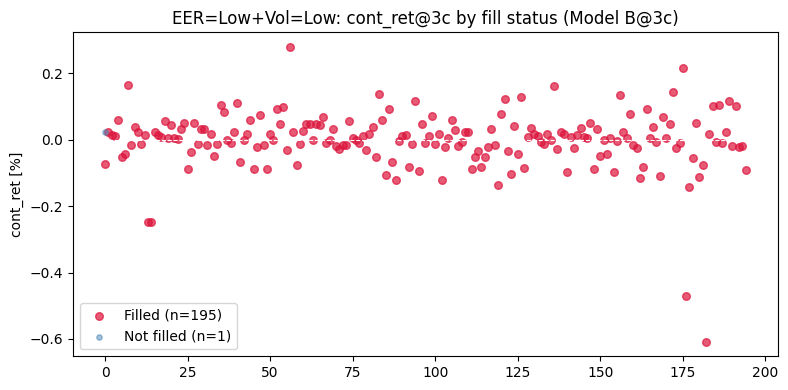

Filled mean: -0.0012%  |  Unfilled mean: +0.0249%
Cell 6 OK


In [17]:
# Q2b — Missed Opportunity Ratio (MOR)
print(SEP)
print('Q2b - MISSED OPPORTUNITY RATIO (MOR)')
print('MOR = P(signal profitable AND not filled)')
print('High MOR: profitable signals escape before limit order fills')
print(SEP)

ret_col = f'cont_{PRIMARY_HORIZON}c'

for label, subset, fill_dict in [
    ('ALL burst events',          sig_all,  fills_all),
    ('EER=Low+Vol=Low (primary)', sig_prim, fills_prim),
]:
    print(f'\n  {label} (n={len(subset)}):')
    profitable = subset[ret_col] > 0
    print(f'  P(profitable@{PRIMARY_HORIZON}c) = {profitable.mean()*100:.1f}%')
    print(f'  {"Model":<8}  {"P(fill)":>8}  {"MOR":>8}  Interpretation')
    for h in FILL_HORIZONS:
        for m in ['B', 'C', 'D']:
            key = f'fill_{m}_{h}c'
            if key not in subset.columns:
                continue
            filled   = subset[key]
            not_fill = ~filled
            mor      = (profitable & not_fill).mean()
            p_fill   = filled.mean()
            interp = 'CRITICAL (good trades escape)' if mor > 0.30 else (
                     'Elevated' if mor > 0.20 else 'Normal')
            print(f'  {m}@{h}c    {p_fill*100:>7.1f}%  {mor*100:>7.1f}%  {interp}')

# Scatter: return vs fill flag (primary bin)
if len(sig_prim) > 5 and 'fill_B_3c' in sig_prim.columns:
    filled_ret   = sig_prim.loc[sig_prim['fill_B_3c'], ret_col].dropna() * 100
    unfilled_ret = sig_prim.loc[~sig_prim['fill_B_3c'], ret_col].dropna() * 100
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(range(len(filled_ret)),   filled_ret,   color='crimson',
               alpha=0.7, s=30, label=f'Filled (n={len(filled_ret)})')
    ax.scatter(range(len(unfilled_ret)), unfilled_ret, color='steelblue',
               alpha=0.5, s=15, label=f'Not filled (n={len(unfilled_ret)})')
    ax.axhline(0, color='white', ls='--', lw=0.8)
    ax.set_title(f'EER=Low+Vol=Low: cont_ret@{PRIMARY_HORIZON}c by fill status (Model B@3c)')
    ax.set_ylabel('cont_ret [%]'); ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '08a_scatter_fill_ret.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Filled mean: {filled_ret.mean():+.4f}%  |  Unfilled mean: {unfilled_ret.mean():+.4f}%')
    if len(filled_ret) > 3 and len(unfilled_ret) > 3:
        t, p = stats.ttest_ind(filled_ret, unfilled_ret, alternative='less')
        sig_str = '*** AS confirmed' if p < 0.05 else 'ns'
        print(f'  t-test filled<unfilled: t={t:.2f}  p={p:.4f}  {sig_str}')

print('Cell 6 OK')


In [18]:
# Q3 — Expectancy by Fill Model (mean + median + tail decomposition)
print(SEP)
print('Q3 - EXPECTANCY BY FILL MODEL')
print('mean + median + tail — mean alone can be driven by outliers')
print(SEP)

ret_col = f'cont_{PRIMARY_HORIZON}c'

def expectancy_table(subset, fill_dict, label):
    print(f'\n  {label} (n={len(subset)}):')
    ret_s = subset[ret_col].dropna()
    print(f'  {"Model":<10}  {"n":>6}  {"E[mean]%":>10}  {"E[med]%":>10}  '
          f'{"E_net+reb%":>12}  {"P(>0)":>7}  {"P95":>10}')

    # Model A (entry at open_C+1)
    ret_A = ((subset[f'fwd_c{PRIMARY_HORIZON}'] - subset['fwd_open1'])
             * subset['dir_sign'] / subset['fwd_open1']).dropna()
    e_A_net = ret_A.mean() + abs(MAKER_REBATE)
    print(f'  {"A(open+1)":<10}  {len(ret_A):>6}  {ret_A.mean()*100:>+9.5f}%  '
          f'{ret_A.median()*100:>+9.5f}%  {e_A_net*100:>+11.5f}%  '
          f'{(ret_A>0).mean()*100:>6.1f}%  {ret_A.quantile(0.95)*100:>+9.5f}%')

    e_nets = [e_A_net]
    for h in FILL_HORIZONS:
        for m in ['B', 'C', 'D']:
            fc = f'fill_{m}_{h}c'
            if fc not in subset.columns: continue
            filled  = subset[fc]
            ret_f   = subset.loc[filled[filled].index, ret_col].dropna()
            if len(ret_f) < 3: continue
            e_net = ret_f.mean() + abs(MAKER_REBATE)
            e_nets.append(e_net)
            print(f'  {m+"@"+str(h)+"c":<10}  {len(ret_f):>6}  {ret_f.mean()*100:>+9.5f}%  '
                  f'{ret_f.median()*100:>+9.5f}%  {e_net*100:>+11.5f}%  '
                  f'{(ret_f>0).mean()*100:>6.1f}%  {ret_f.quantile(0.95)*100:>+9.5f}%')

    # Fantasy row
    e_fan = ret_s.mean() + abs(MAKER_REBATE)
    print(f'  {"Fantasy":<10}  {len(ret_s):>6}  {ret_s.mean()*100:>+9.5f}%  '
          f'{ret_s.median()*100:>+9.5f}%  {e_fan*100:>+11.5f}%  '
          f'{(ret_s>0).mean()*100:>6.1f}%  {ret_s.quantile(0.95)*100:>+9.5f}%')

    if len(e_nets) > 1:
        delta = max(e_nets) - min(e_nets)
        best  = max(e_nets)
        print(f'\n  Sensitivity (max-min E_net): {delta*100:.5f}%')
        if best <= 0:
            print('  FAIL: E_net <= 0 across all fill models')
        elif delta > abs(best):
            print('  WARN: result NOT robust — fill assumption dominates E_net')
        else:
            print('  OK: result relatively robust to fill assumption')
    return e_nets

e_nets_all  = expectancy_table(sig_all,  fills_all,  'ALL burst events')
e_nets_prim = expectancy_table(sig_prim, fills_prim, 'EER=Low+Vol=Low (primary)')
print('Cell 7 OK')


Q3 - EXPECTANCY BY FILL MODEL
mean + median + tail — mean alone can be driven by outliers

  ALL burst events (n=37625):
  Model            n    E[mean]%     E[med]%    E_net+reb%    P(>0)         P95
  A(open+1)    37625   +0.00093%   -0.00035%     +0.02093%    48.3%   +0.15611%
  B@1c         36876   -0.00023%   -0.00110%     +0.01977%    47.7%   +0.15277%
  C@1c         20681   -0.02157%   -0.02323%     -0.00157%    34.9%   +0.15562%
  D@1c         18270   -0.04165%   -0.02878%     -0.02165%    26.3%   +0.07395%
  B@3c         37153   -0.00028%   -0.00127%     +0.01972%    47.6%   +0.15244%
  C@3c         26305   -0.02191%   -0.02207%     -0.00191%    31.8%   +0.13366%
  D@3c         19100   -0.06493%   -0.04041%     -0.04493%     0.0%   -0.00306%
  B@5c         37251   -0.00014%   -0.00110%     +0.01986%    47.7%   +0.15251%
  C@5c         28518   -0.01851%   -0.01760%     +0.00149%    34.8%   +0.12947%
  D@5c         19179   -0.05226%   -0.03353%     -0.03226%    19.1%   +0.03915%

In [19]:
# Q4 — Gap Ratio Compression (taker vs maker)
print(SEP)
print('Q4 - GAP RATIO COMPRESSION')
print('Taker baseline from Exp07: ~400x gap (required/observed drift)')
print(f'Does maker rebate reduce this to < {GAP_RATIO_GO}x?')
print(SEP)

ret_col = f'cont_{PRIMARY_HORIZON}c'

for label, subset, fill_dict in [
    ('ALL burst events',          sig_all,  fills_all),
    ('EER=Low+Vol=Low (primary)', sig_prim, fills_prim),
]:
    print(f'\n  {label} (n={len(subset)}):')
    ret_s     = subset[ret_col].dropna()
    obs_drift = ret_s.mean()
    taker_gap = TAKER_COST / abs(obs_drift) if abs(obs_drift) > 1e-10 else float('inf')
    print(f'  Observed drift (signal mean): {obs_drift*100:+.5f}%')
    print(f'  Taker gap ratio: {taker_gap:.0f}x')
    print()
    print(f'  {"Model":<10}  {"P(fill)":>8}  {"Adj drift":>12}  {"Eff Gap Ratio":>14}  Verdict')

    for h in FILL_HORIZONS:
        for m in ['B', 'C', 'D']:
            fc = f'fill_{m}_{h}c'
            if fc not in subset.columns: continue
            filled  = subset[fc]
            p_fill  = filled.mean()
            if p_fill < 1e-6: continue
            ret_f   = subset.loc[filled[filled].index, ret_col].dropna()
            # fill-adjusted monetizable drift
            adj_drift = ret_f.mean() * p_fill if len(ret_f) >= 3 else np.nan
            if np.isnan(adj_drift) or abs(adj_drift) < 1e-10:
                print(f'  {m+"@"+str(h)+"c":<10}  {p_fill*100:>7.1f}%  {"N/A":>12}  {"inf":>14}x  FAIL')
                continue
            eff_gap = TAKER_COST / abs(adj_drift)
            verdict = 'PASS (<5x)' if eff_gap < GAP_RATIO_GO else 'FAIL'
            print(f'  {m+"@"+str(h)+"c":<10}  {p_fill*100:>7.1f}%  '
                  f'{adj_drift*100:>+11.5f}%  {eff_gap:>13.1f}x  {verdict}')

print()
print('NOTE: Eff. Gap Ratio < 5x is necessary but NOT sufficient — FQR > 0.70 also required.')
print('Cell 8 OK')


Q4 - GAP RATIO COMPRESSION
Taker baseline from Exp07: ~400x gap (required/observed drift)
Does maker rebate reduce this to < 5.0x?

  ALL burst events (n=37625):
  Observed drift (signal mean): +0.00094%
  Taker gap ratio: 85x

  Model        P(fill)     Adj drift   Eff Gap Ratio  Verdict
  B@1c           98.0%     -0.00022%          359.4x  FAIL
  C@1c           55.0%     -0.01186%            6.7x  FAIL
  D@1c           48.6%     -0.02022%            4.0x  PASS (<5x)
  B@3c           98.7%     -0.00028%          288.9x  FAIL
  C@3c           69.9%     -0.01532%            5.2x  FAIL
  D@3c           50.8%     -0.03296%            2.4x  PASS (<5x)
  B@5c           99.0%     -0.00013%          596.9x  FAIL
  C@5c           75.8%     -0.01403%            5.7x  FAIL
  D@5c           51.0%     -0.02664%            3.0x  PASS (<5x)

  EER=Low+Vol=Low (primary) (n=196):
  Observed drift (signal mean): -0.00107%
  Taker gap ratio: 75x

  Model        P(fill)     Adj drift   Eff Gap Ratio  Ver

In [20]:
# EER x Vol Bin Heatmap: FQR and fill probability
print(SEP)
print('BIN ANALYSIS - FQR and fill probability across all EER x Vol bins')
print('Identifying whether any bin is viable, not just the primary candidate')
print(SEP)

ret_col   = f'cont_{PRIMARY_HORIZON}c'
REF_MODEL = f'fill_B_{PRIMARY_HORIZON}c'

EER_LABS = ['High', 'Med', 'Low']
VOL_LABS = ['Low',  'Med', 'High']

bursts = train[train['is_burst']].dropna(subset=[ret_col, 'eer_bucket', 'vol_bucket']).copy()

# Compute fill flags on all bursts
cl0  = bursts['close']
eps  = cl0 * FILL_EPSILON
lm   = bursts['dir_sign'] ==  1.0
sm   = bursts['dir_sign'] == -1.0
for h in FILL_HORIZONS:
    minl = bursts[f'fwd_min_low_{h}']
    maxh = bursts[f'fwd_max_high_{h}']
    bursts[f'fill_B_{h}c'] = (lm & (minl <= cl0)) | (sm & (maxh >= cl0))
    bursts[f'fill_C_{h}c'] = (lm & (minl < cl0 - eps)) | (sm & (maxh > cl0 + eps))

fqr_mat   = np.full((3, 3), np.nan)
pfill_mat = np.full((3, 3), np.nan)
pcont_mat = np.full((3, 3), np.nan)
n_mat     = np.zeros((3, 3), dtype=int)
MIN_N     = 50

for i, eer_b in enumerate(EER_LABS):
    for j, vol_b in enumerate(VOL_LABS):
        sub = bursts[(bursts['eer_bucket'] == eer_b) & (bursts['vol_bucket'] == vol_b)]
        n_mat[i, j] = len(sub)
        if len(sub) < MIN_N:
            continue
        ret_s = sub[ret_col].dropna()
        e_s   = ret_s.mean()
        pcont_mat[i, j] = ret_s.gt(0).mean() * 100
        if REF_MODEL in sub.columns:
            fm = sub[REF_MODEL]
            pfill_mat[i, j] = fm.mean() * 100
            ret_f = sub.loc[fm[fm].index, ret_col].dropna()
            if len(ret_f) >= 5 and abs(e_s) > 1e-10:
                fqr_mat[i, j] = ret_f.mean() / e_s

print(f'P(cont@{PRIMARY_HORIZON}c) by bin [%]:')
print(f'  {"EER\\Vol":<10}' + ''.join(f'  {v:>12}' for v in VOL_LABS))
for i, eer_b in enumerate(EER_LABS):
    row = f'  {"EER="+eer_b:<10}'
    for j in range(3):
        n = n_mat[i, j]; v = pcont_mat[i, j]
        row += f'  {v:>7.1f}%(n={n})' if not np.isnan(v) else f'  {"<min":>7}(n={n})'
    print(row)

print(f'\nFQR (Model B@{PRIMARY_HORIZON}c):')
print(f'  {"EER\\Vol":<10}' + ''.join(f'  {v:>12}' for v in VOL_LABS))
for i, eer_b in enumerate(EER_LABS):
    row = f'  {"EER="+eer_b:<10}'
    for j in range(3):
        v = fqr_mat[i, j]
        flag = '[FAIL]' if (not np.isnan(v) and v < FQR_GO) else ''
        row += f'  {v:>7.3f}{flag:>5}' if not np.isnan(v) else f'  {"N/A":>12}'
    print(row)

print(f'\nP(fill@{PRIMARY_HORIZON}c, Model B) [%]:')
print(f'  {"EER\\Vol":<10}' + ''.join(f'  {v:>12}' for v in VOL_LABS))
for i, eer_b in enumerate(EER_LABS):
    row = f'  {"EER="+eer_b:<10}'
    for j in range(3):
        v = pfill_mat[i, j]
        row += f'  {v:>10.1f}%' if not np.isnan(v) else f'  {"N/A":>12}'
    print(row)

print('Cell 9 OK')


BIN ANALYSIS - FQR and fill probability across all EER x Vol bins
Identifying whether any bin is viable, not just the primary candidate
P(cont@3c) by bin [%]:
  EER\Vol              Low           Med          High
  EER=High       51.9%(n=5457)     49.1%(n=14203)     45.2%(n=9009)
  EER=Med        48.8%(n=379)     47.5%(n=2237)     46.4%(n=2762)
  EER=Low        55.1%(n=196)     48.9%(n=1355)     48.1%(n=2023)

FQR (Model B@3c):
  EER\Vol              Low           Med          High
  EER=High      0.725         0.584[FAIL]    2.637     
  EER=Med       0.589[FAIL]    1.552         3.126     
  EER=Low       1.124         0.453[FAIL]    1.480     

P(fill@3c, Model B) [%]:
  EER\Vol              Low           Med          High
  EER=High          98.4%        98.8%        98.9%
  EER=Med           97.9%        99.0%        98.7%
  EER=Low           99.5%        99.3%        98.5%
Cell 9 OK


ADVERSE SELECTION CURVES
E[cont_ret@N | filled] vs E[cont_ret@N | signal]
Divergence slope D(N) = E[filled@N] - E[signal@N]
Negative and steepening -> adverse selection accumulates over time
Fill Model B@1c: filled=36,932  not_filled=749

   Horizon     E[signal]     E[filled]     E[nofill]        D(N)
        1c     -0.00015%     -0.00134%     +0.05810%   -0.00118%
        3c     +0.00094%     -0.00023%     +0.05822%   -0.00116%
        5c     +0.00033%     -0.00083%     +0.05737%   -0.00116%
       10c     -0.00011%     -0.00129%     +0.05809%   -0.00118%
       20c     -0.00171%     -0.00273%     +0.04892%   -0.00103%

Divergence slope D(N+1) - D(N):
  1c->3c: +0.00002%  recovering
  3c->5c: +0.00000%  recovering
  5c->10c: -0.00002%  accumulating AS
  10c->20c: +0.00015%  recovering


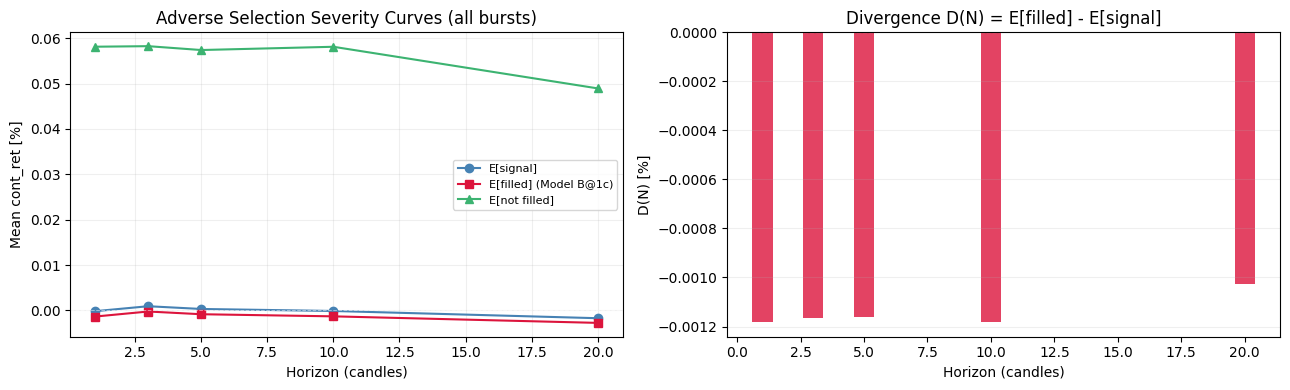

Saved: 08a_adverse_selection.png
Cell 10 OK


In [21]:
# Adverse Selection Severity Curves + Divergence Slope
print(SEP)
print('ADVERSE SELECTION CURVES')
print('E[cont_ret@N | filled] vs E[cont_ret@N | signal]')
print('Divergence slope D(N) = E[filled@N] - E[signal@N]')
print('Negative and steepening -> adverse selection accumulates over time')
print(SEP)

bursts = train[train['is_burst']].copy()
cl0    = bursts['close']
lm     = bursts['dir_sign'] ==  1.0
sm     = bursts['dir_sign'] == -1.0
minl1  = bursts['fwd_min_low_1']
maxh1  = bursts['fwd_max_high_1']
bursts['fill_B1'] = (lm & (minl1 <= cl0)) | (sm & (maxh1 >= cl0))

filled_sub = bursts[bursts['fill_B1']]
nofill_sub = bursts[~bursts['fill_B1']]

print(f'Fill Model B@1c: filled={bursts["fill_B1"].sum():,}  not_filled={(~bursts["fill_B1"]).sum():,}')
print()
print(f'  {"Horizon":>8}  {"E[signal]":>12}  {"E[filled]":>12}  {"E[nofill]":>12}  {"D(N)":>10}')
deltas = []
e_sig_curve, e_fil_curve, e_nof_curve = [], [], []
for h in FWD_HORIZONS:
    col = f'cont_{h}c'
    e_s = bursts[col].mean()
    e_f = filled_sub[col].mean()
    e_n = nofill_sub[col].mean()
    d   = e_f - e_s
    deltas.append(d)
    e_sig_curve.append(e_s * 100); e_fil_curve.append(e_f * 100); e_nof_curve.append(e_n * 100)
    print(f'  {h:>7}c  {e_s*100:>+11.5f}%  {e_f*100:>+11.5f}%  {e_n*100:>+11.5f}%  {d*100:>+9.5f}%')

print()
slopes = [deltas[i+1] - deltas[i] for i in range(len(deltas)-1)]
print('Divergence slope D(N+1) - D(N):')
for h1, h2, slope in zip(FWD_HORIZONS, FWD_HORIZONS[1:], slopes):
    trend = 'accumulating AS' if slope < 0 else 'recovering'
    print(f'  {h1}c->{h2}c: {slope*100:>+8.5f}%  {trend}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(FWD_HORIZONS, e_sig_curve, 'o-', color='steelblue',      label='E[signal]')
ax.plot(FWD_HORIZONS, e_fil_curve, 's-', color='crimson',        label='E[filled] (Model B@1c)')
ax.plot(FWD_HORIZONS, e_nof_curve, '^-', color='mediumseagreen', label='E[not filled]')
ax.axhline(0, color='white', ls='--', lw=0.7, alpha=0.5)
ax.set_title('Adverse Selection Severity Curves (all bursts)')
ax.set_xlabel('Horizon (candles)'); ax.set_ylabel('Mean cont_ret [%]')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes[1]
dcurve = [d * 100 for d in deltas]
cols   = ['crimson' if d < 0 else 'mediumseagreen' for d in dcurve]
ax.bar(FWD_HORIZONS, dcurve, color=cols, alpha=0.8)
ax.axhline(0, color='white', ls='--', lw=0.8)
ax.set_title('Divergence D(N) = E[filled] - E[signal]')
ax.set_xlabel('Horizon (candles)'); ax.set_ylabel('D(N) [%]')
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '08a_adverse_selection.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: 08a_adverse_selection.png')
print('Cell 10 OK')


In [22]:
# Robustness: yearly + ATR-regime split
print(SEP)
print('ROBUSTNESS - FQR stability by year and ATR regime')
print('Unstable FQR -> regime-specific, not structural')
print(SEP)

ret_col = f'cont_{PRIMARY_HORIZON}c'
REF_FC  = 'fill_B_3c'

bursts = train[train['is_burst']].dropna(subset=[ret_col]).copy()
cl0    = bursts['close']
lm     = bursts['dir_sign'] ==  1.0
sm     = bursts['dir_sign'] == -1.0
minl3  = bursts['fwd_min_low_3']
maxh3  = bursts['fwd_max_high_3']
bursts[REF_FC] = (lm & (minl3 <= cl0)) | (sm & (maxh3 >= cl0))
bursts['year'] = pd.to_datetime(bursts['open_time']).dt.year

print('\nYearly FQR (Model B@3c):')
print(f'  {"Year":<6}  {"n":>6}  {"E[signal]":>11}  {"P(fill)":>8}  {"E[filled]":>11}  {"FQR":>7}')
for year, grp in bursts.groupby('year'):
    ret_s = grp[ret_col].dropna(); e_s = ret_s.mean()
    if len(ret_s) < 20: continue
    fm    = grp[REF_FC]; p_f = fm.mean()
    ret_f = grp.loc[fm[fm].index, ret_col].dropna(); e_f = ret_f.mean()
    fqr   = e_f / e_s if abs(e_s) > 1e-10 else np.nan
    flag  = ' FAIL' if (not np.isnan(fqr) and fqr < FQR_GO) else ''
    print(f'  {year:<6}  {len(ret_s):>6}  {e_s*100:>+10.5f}%  '
          f'{p_f*100:>7.1f}%  {e_f*100:>+10.5f}%  {fqr:>7.3f}{flag}')

bursts['atr_q'] = pd.qcut(bursts['atr'], q=4,
    labels=['Q1_low', 'Q2', 'Q3', 'Q4_high'], duplicates='drop')

print('\nATR-regime FQR (Q1=low vol, Q4=high vol):')
print(f'  {"Regime":<10}  {"n":>6}  {"E[signal]":>11}  {"P(fill)":>8}  {"E[filled]":>11}  {"FQR":>7}')
for regime, grp in bursts.groupby('atr_q', observed=True):
    ret_s = grp[ret_col].dropna(); e_s = ret_s.mean()
    if len(ret_s) < 20: continue
    fm    = grp[REF_FC]; p_f = fm.mean()
    ret_f = grp.loc[fm[fm].index, ret_col].dropna(); e_f = ret_f.mean()
    fqr   = e_f / e_s if abs(e_s) > 1e-10 else np.nan
    flag  = ' FAIL' if (not np.isnan(fqr) and fqr < FQR_GO) else ''
    print(f'  {str(regime):<10}  {len(ret_s):>6}  {e_s*100:>+10.5f}%  '
          f'{p_f*100:>7.1f}%  {e_f*100:>+10.5f}%  {fqr:>7.3f}{flag}')

print()
print('Key: range(FQR across years) > 1.0 -> regime-specific, not structural')
print('Cell 11 OK')


ROBUSTNESS - FQR stability by year and ATR regime
Unstable FQR -> regime-specific, not structural

Yearly FQR (Model B@3c):
  Year         n    E[signal]   P(fill)    E[filled]      FQR
  2025     27763    +0.00085%     98.7%    -0.00031%   -0.363 FAIL
  2026      9862    +0.00119%     98.9%    -0.00020%   -0.172 FAIL

ATR-regime FQR (Q1=low vol, Q4=high vol):
  Regime           n    E[signal]   P(fill)    E[filled]      FQR
  Q1_low        9407    +0.00176%     98.9%    +0.00133%    0.756
  Q2            9406    +0.00124%     98.7%    +0.00047%    0.377 FAIL
  Q3            9406    +0.00090%     98.7%    -0.00020%   -0.222 FAIL
  Q4_high       9406    -0.00016%     98.6%    -0.00273%   17.178

Key: range(FQR across years) > 1.0 -> regime-specific, not structural
Cell 11 OK


In [23]:
# HET — Hidden Execution Tax
print(SEP)
print('HET - HIDDEN EXECUTION TAX')
print('HET = E_net[fantasy] - E_net[retail]')
print('Quantifies: how much of the maker edge is simulation artifact')
print(SEP)

ret_col = f'cont_{PRIMARY_HORIZON}c'

for label, subset, fill_dict in [
    ('ALL burst events',          sig_all,  fills_all),
    ('EER=Low+Vol=Low (primary)', sig_prim, fills_prim),
]:
    print(f'\n  {label} (n={len(subset)}):')
    ret_s    = subset[ret_col].dropna()
    e_taker  = ret_s.mean() - TAKER_COST
    e_fantasy = ret_s.mean() + abs(MAKER_REBATE)

    print(f'  {"Scenario":<22}  {"E_net":>11}  {"HET vs fantasy":>16}  Notes')
    print(f'  {"Taker baseline":<22}  {e_taker*100:>+10.5f}%  {"---":>16}  Exp01-07 cost model')
    print(f'  {"Fantasy maker":<22}  {e_fantasy*100:>+10.5f}%  {0.0:>+15.5f}%  instant fill, no AS')

    for h in FILL_HORIZONS:
        for m in ['B', 'C', 'D']:
            fc = f'fill_{m}_{h}c'
            if fc not in subset.columns: continue
            filled = subset[fc]
            ret_f  = subset.loc[filled[filled].index, ret_col].dropna()
            if len(ret_f) < 3: continue
            e_retail = ret_f.mean() + abs(MAKER_REBATE)
            het      = e_fantasy - e_retail
            note     = f'P(fill)={filled.mean()*100:.0f}%'
            large    = '  <- LARGE HET' if het > 0.0002 else ''
            print(f'  {"Retail "+m+"@"+str(h)+"c":<22}  {e_retail*100:>+10.5f}%  '
                  f'{het*100:>+15.5f}%  {note}{large}')

    print()
    print(f'  Interpretation: if E_net[retail] < 0 while E_net[fantasy] > 0 ->')
    print(f'  HET fully explains the gap. The edge exists only under fantasy assumptions.')

print('Cell 12 OK')


HET - HIDDEN EXECUTION TAX
HET = E_net[fantasy] - E_net[retail]
Quantifies: how much of the maker edge is simulation artifact

  ALL burst events (n=37625):
  Scenario                      E_net    HET vs fantasy  Notes
  Taker baseline            -0.07906%               ---  Exp01-07 cost model
  Fantasy maker             +0.02094%         +0.00000%  instant fill, no AS
  Retail B@1c               +0.01977%         +0.00116%  P(fill)=98%
  Retail C@1c               -0.00157%         +0.02251%  P(fill)=55%  <- LARGE HET
  Retail D@1c               -0.02165%         +0.04259%  P(fill)=49%  <- LARGE HET
  Retail B@3c               +0.01972%         +0.00122%  P(fill)=99%
  Retail C@3c               -0.00191%         +0.02284%  P(fill)=70%  <- LARGE HET
  Retail D@3c               -0.04493%         +0.06586%  P(fill)=51%  <- LARGE HET
  Retail B@5c               +0.01986%         +0.00107%  P(fill)=99%
  Retail C@5c               +0.00149%         +0.01944%  P(fill)=76%
  Retail D@5c     

In [24]:
# Cell 13 — Execution Feasibility Summary + Decision Tree
SEP2 = '=' * 70
print(SEP2)
print('  EXP 08a - MAKER EXECUTION FEASIBILITY SUMMARY')
print(f'  SPEC_HASH: {SPEC_HASH}')
print(f'  Prior: Exp07 c4eea0bd7574  |  Signal: EER=Low+Vol=Low, TR/ATR>{ATR_THRESH}')
print(SEP2)

ret_col = f'cont_{PRIMARY_HORIZON}c'

def get_fqr_val(subset, fill_col):
    if fill_col not in subset.columns: return np.nan, np.nan
    ret_s = subset[ret_col].dropna(); e_s = ret_s.mean()
    fm    = subset[fill_col]
    ret_f = subset.loc[fm[fm].index, ret_col].dropna()
    if len(ret_f) < 3 or abs(e_s) < 1e-10: return np.nan, fm.mean()
    return ret_f.mean() / e_s, fm.mean()

def get_eff_gap(subset, fill_col):
    if fill_col not in subset.columns: return np.inf
    fm    = subset[fill_col]; p_f = fm.mean()
    if p_f < 1e-6: return np.inf
    ret_f = subset.loc[fm[fm].index, ret_col].dropna()
    if len(ret_f) < 3: return np.inf
    adj = ret_f.mean() * p_f
    return TAKER_COST / abs(adj) if abs(adj) > 1e-10 else np.inf

FC_REF = f'fill_B_{PRIMARY_HORIZON}c'
fqr_prim, p_fill_prim = get_fqr_val(sig_prim, FC_REF)
eff_gap  = get_eff_gap(sig_prim, FC_REF)

e_nets = []
for h in FILL_HORIZONS:
    for m in ['B', 'C', 'D']:
        fc = f'fill_{m}_{h}c'
        if fc not in sig_prim.columns: continue
        fm   = sig_prim[fc]
        ret_f = sig_prim.loc[fm[fm].index, ret_col].dropna()
        if len(ret_f) >= 3:
            e_nets.append(ret_f.mean() + abs(MAKER_REBATE))
robust = all(e > 0 for e in e_nets) if e_nets else False

print()
print(f'  PRIMARY BIN: EER=Low+Vol=Low  (n_train = {len(sig_prim)})')
print()

cr1 = not np.isnan(fqr_prim) and fqr_prim > FQR_GO
cr2 = eff_gap < GAP_RATIO_GO
cr3 = robust

def tick(ok): return '[PASS]' if ok else '[FAIL]'

print(f'  {tick(cr1)} FQR > {FQR_GO}          -> observed FQR = {fqr_prim:.3f}  (Model B@{PRIMARY_HORIZON}c)')
print(f'  {tick(cr2)} Eff. Gap < {GAP_RATIO_GO}x       -> observed = {eff_gap:.1f}x')
print(f'  {tick(cr3)} E_net robust            -> {sum(1 for e in e_nets if e>0)}/{len(e_nets)} models positive')
print()

all_pass = cr1 and cr2 and cr3

if all_pass:
    verdict = 'FEASIBLE -> proceed to Exp08b (full maker strategy backtest with holdout)'
elif not cr1 and not cr2:
    verdict = 'NOT FEASIBLE: adverse selection AND gap ratio both fail'
elif not cr1:
    verdict = 'NOT FEASIBLE: adverse selection dominates (FQR below threshold)'
elif not cr2:
    verdict = 'NOT FEASIBLE: effective gap ratio too large for rebate to bridge'
else:
    verdict = 'BORDERLINE: review individual metrics before deciding'

print(f'  VERDICT: {verdict}')
print()

if not all_pass:
    print('  POST-MORTEM (NOT FEASIBLE):')
    print()
    print('  Bounded Claim (updated by Exp08a):')
    print('  {OHLCV, M1, retail taker OR retail maker} -> directional alpha ~= 0')
    print('  4 signal families + execution survivability test = strong conclusion.')
    print()
    print('  Decision tree:')
    print()
    print('  Path B — M5/M15 native hypotheses (recommended first step)')
    print('    + Same research infrastructure, no new data required')
    print('    + Cost/move ratio improves substantially at longer horizons')
    print('    + Exp03 falsified stochastic M5 — NOT native M5 hypotheses')
    print('    Candidates: funding divergence, session gap, OI momentum')
    print()
    print('  Path A — L2 book microstructure')
    print('    + Edge may exist in book imbalance / absorption dynamics')
    print('    - New data infrastructure (order book snapshots + trades feed)')
    print('    - Retail maker still faces adverse selection and queue competition')
    print()
    print('  Path C — Liquidation cascade mechanics')
    print('    + Mechanical, predictable flow (not directional forecasting)')
    print('    - Infrequent events, requires real-time OI + liquidation data')

print()
print(SEP2)
print('Cell 13 OK - Exp08a complete')


  EXP 08a - MAKER EXECUTION FEASIBILITY SUMMARY
  SPEC_HASH: 3875a863a4fe
  Prior: Exp07 c4eea0bd7574  |  Signal: EER=Low+Vol=Low, TR/ATR>2.0

  PRIMARY BIN: EER=Low+Vol=Low  (n_train = 196)

  [PASS] FQR > 0.7          -> observed FQR = 1.124  (Model B@3c)
  [FAIL] Eff. Gap < 5.0x       -> observed = 66.8x
  [FAIL] E_net robust            -> 3/9 models positive

  VERDICT: NOT FEASIBLE: effective gap ratio too large for rebate to bridge

  POST-MORTEM (NOT FEASIBLE):

  Bounded Claim (updated by Exp08a):
  {OHLCV, M1, retail taker OR retail maker} -> directional alpha ~= 0
  4 signal families + execution survivability test = strong conclusion.

  Decision tree:

  Path B — M5/M15 native hypotheses (recommended first step)
    + Same research infrastructure, no new data required
    + Cost/move ratio improves substantially at longer horizons
    + Exp03 falsified stochastic M5 — NOT native M5 hypotheses
    Candidates: funding divergence, session gap, OI momentum

  Path A — L2 book mi